# Convolutional Neural Networks

In principle, a Convolutional Neural Network (CNN) works by applying different **kernels**, these kernels then generate multiple filtered versions of the signal. These signals are then processed with an *activation function* (i.e. a nonlinearity). The convolution is applied with a stride>1 so that the length of the output signal is reduced. This process is repeated multiple times until a desired output dimension is obtained. 

<div style="text-align:center">
<img src="images/Schematic-of-1DCNN.jpg" alt="plot" width="400" />
</div>

Typically, the convolution ends in a long vector that is called the **embedding**. This embedding is a representation of the input signal after being transformed by the CNN. The embedding is then used as the input of a *Fully Connected* (FC) layer, which is a regular artificial neural network, the output of this FC layer depends on the problem at hand. For instance, it could correspond to probability in the case of classification, or to a float number in the case of regression. 

The key aspect about CNN is that the kernels are not predefined (as in out previous notebook), rather, they are learned from data using gradient descent (or a modified version of it). You need to define how many kernels should be used and how many layers should be included, and then use training data to find the kernel parameters.

In this notebook we will build a small convolutional neural network to demonstrate their basic functionalities. For this, we will use a special python library called **PyTorch** (www.pytorch.com) which includes all the elements to design and train these networks. I don't expect you to learn how to use this library, so this example is mostly to show you how all this works. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

Let us start with a simple layer, it receives one channel (i.e. one signal) and produces two signals, that is, it applies two kernels to the original signal.

We will use a kernel size of 3, similar to the ones we used before. 

In [3]:
conv =  nn.Conv1d(
    in_channels=1,
    out_channels=2,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=True
)

print(conv)
print('Weight shape:', conv.weight.shape)
print('Bias shape:', conv.bias.shape)

Conv1d(1, 2, kernel_size=(3,), stride=(1,), padding=(1,))
Weight shape: torch.Size([2, 1, 3])
Bias shape: torch.Size([2])


For a PyTorch 1D convolution layer, the weight tensor has shape:

$$
(\text{out\_channels}, \text{in\_channels}, \text{kernel\_size})
$$

For example, if:
- `in_channels = 1`
- `out_channels = 2`
- `kernel_size = 3`

In this layer, we will apply **two different learned filters**, each of length 3, to the input signal.

Each kernel is convolved with the signal and produces its own output, often called feature map.

When we created the `conv` element, the parameters of the kernel were assigned randomly. We can use these random kernels to check the output of the layer. 

In [5]:
x = np.array([0, 0, 1, 3, 7, 8, 7, 3, 1, 0, 0], dtype=float)
x_torch = torch.tensor(x, dtype=torch.float32).view(1, 1, -1)  # (batch, channels, length)

with torch.no_grad():
    y_torch = conv(x_torch)

print('Input shape:', x_torch.shape)
print('Output shape:', y_torch.shape)
print('Output tensor:')
print(y_torch)

Input shape: torch.Size([1, 1, 11])
Output shape: torch.Size([1, 2, 11])
Output tensor:
tensor([[[-0.1758, -0.6447, -1.6560, -3.9007, -5.1080, -5.6015, -3.8747,
          -2.4208, -0.9160, -0.3981, -0.1758],
         [ 0.1421, -0.1013, -0.2265,  0.0778,  2.3908,  5.2150,  6.3818,
           4.8671,  2.1681,  0.6969,  0.1421]]])


We can visualize the kernels (remember that these are random numbers)

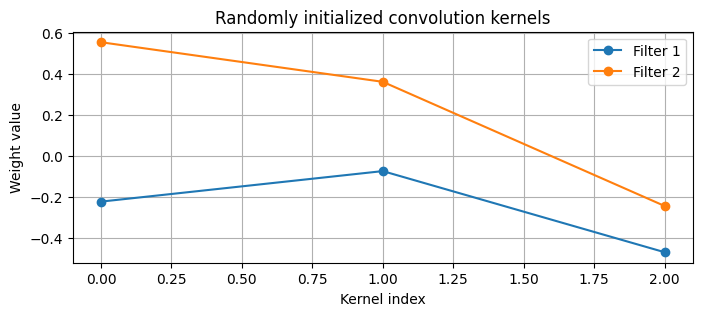

In [6]:
weights = conv.weight.detach().numpy()

plt.figure(figsize=(8, 3))
for i in range(weights.shape[0]):
    plt.plot(weights[i, 0, :], marker='o', label=f'Filter {i+1}')
plt.title('Randomly initialized convolution kernels')
plt.xlabel('Kernel index')
plt.ylabel('Weight value')
plt.grid(True)
plt.legend()
plt.show()

and also visualize the feature maps created by each kernel

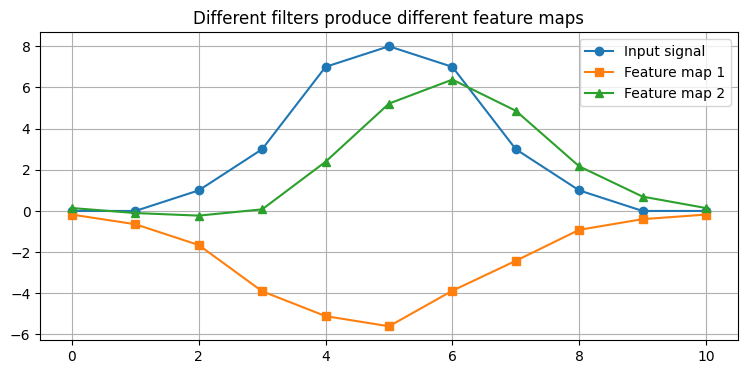

In [7]:
plt.figure(figsize=(9, 4))
plt.plot(x, marker='o', label='Input signal')
plt.plot(y_torch[0, 0].detach().numpy(), marker='s', label='Feature map 1')
plt.plot(y_torch[0, 1].detach().numpy(), marker='^', label='Feature map 2')
plt.title('Different filters produce different feature maps')
plt.grid(True)
plt.legend()
plt.show()

In the next step, each feature map will be processed using a nonlinear activation function (e.g. ReLu, tanh, leaky ReLu) and the output will be then passed through other convolutional layer, producing additional feature maps. 

Note that the size of these networks grow really fast, in this first layer we already have 6 unknown parameters (3 for each kernel). If we add another similar layer, 12 additional unknown parameters, for a total of 18. As you continue increasing the network size, the number of unknown parameters that must be estimated from data grows quickly. 


### A simple example

We can create a simple CNN to classify signals into two classes. The CNN has two layers and 4 kernels in the first layer and 2 kernels in the second layer. So, for each input signal, the CNN will generate a total of 8 signal. 
These 8 signals are then combined to generate a feature map, which is then used as input to a fully connected layer. 

In [63]:
# Create a simple CNN with 2 layer and 4 kernels in each layer

class TinyCNN(nn.Module):
    def __init__(self):
        super(TinyCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=4, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Linear(8,2) 

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        print(x.shape)
        x = self.classifier(x)
        return x

model = TinyCNN()
print(model)

TinyCNN(
  (features): Sequential(
    (0): Conv1d(1, 4, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(4, 8, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Linear(in_features=8, out_features=2, bias=True)
)


## What a 1D CNN does

This simple 1D CNN for classification usually includes:

1. **convolution layer**
   - scans the signal with multiple learned filters
2. **nonlinearity** such as ReLU
   - allows more flexible transformations
3. **additional convolution layers**
   - combine simple patterns into richer features   
4. **pooling or downsampling**
   - compresses information and increases robustness. In this case, it finds the average of the signal. 
5. **final classifier**
   - uses the extracted features to predict the class

The key idea is that the network learns the filters automatically.


We can visualize how the CNN works, we are using random kernels for now

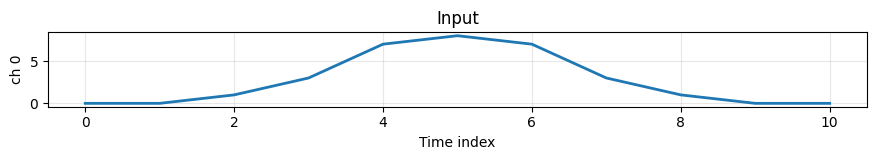

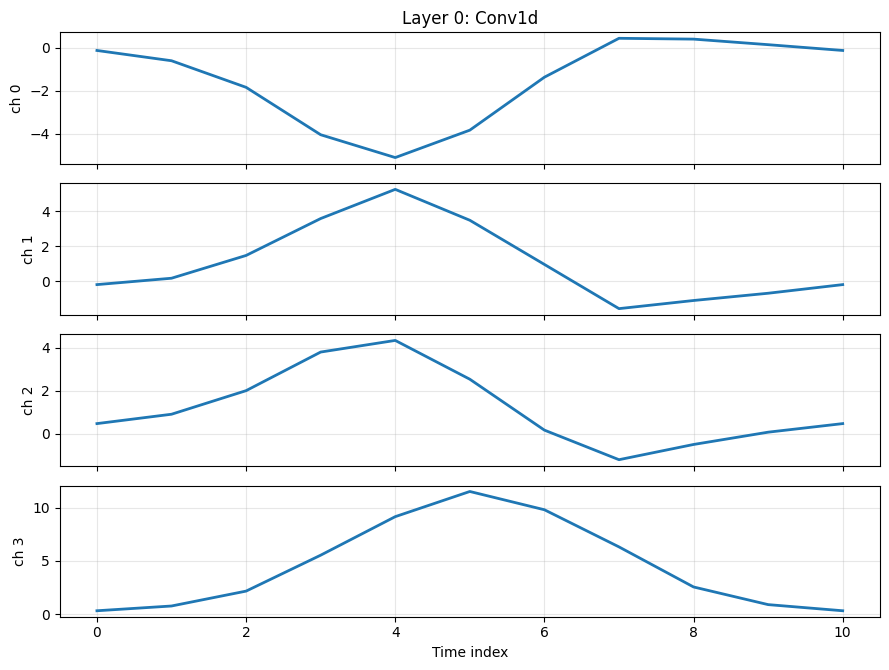

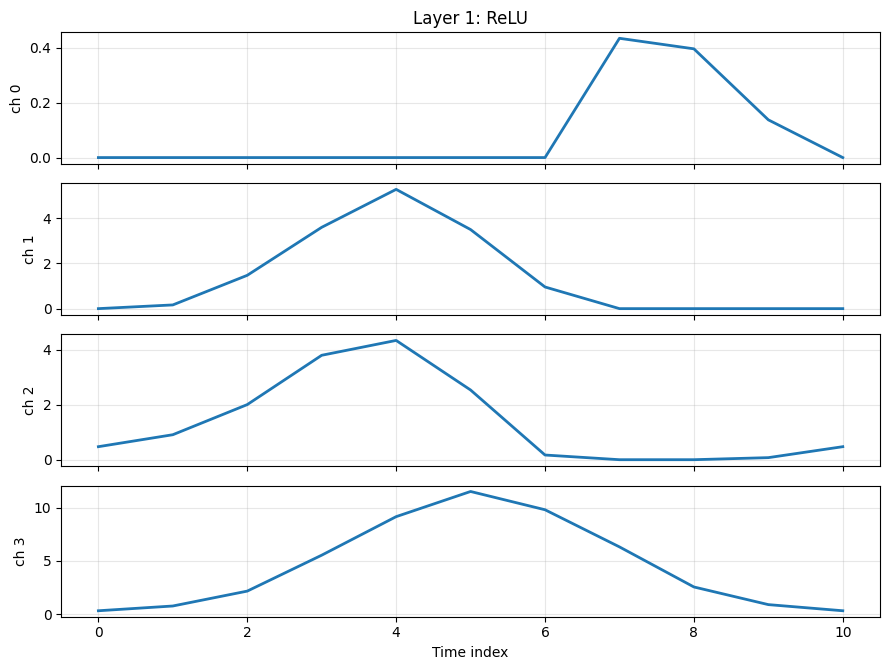

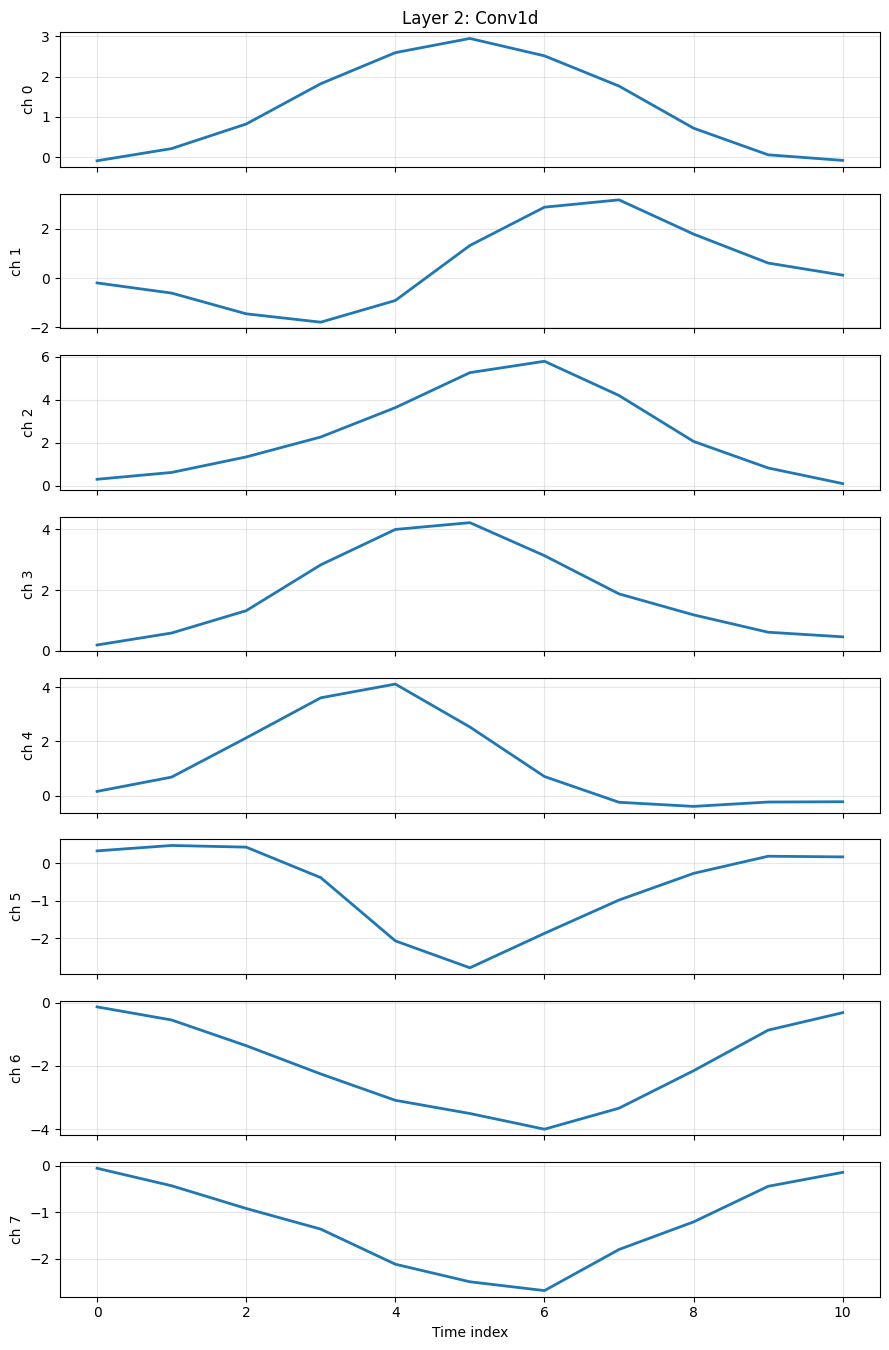

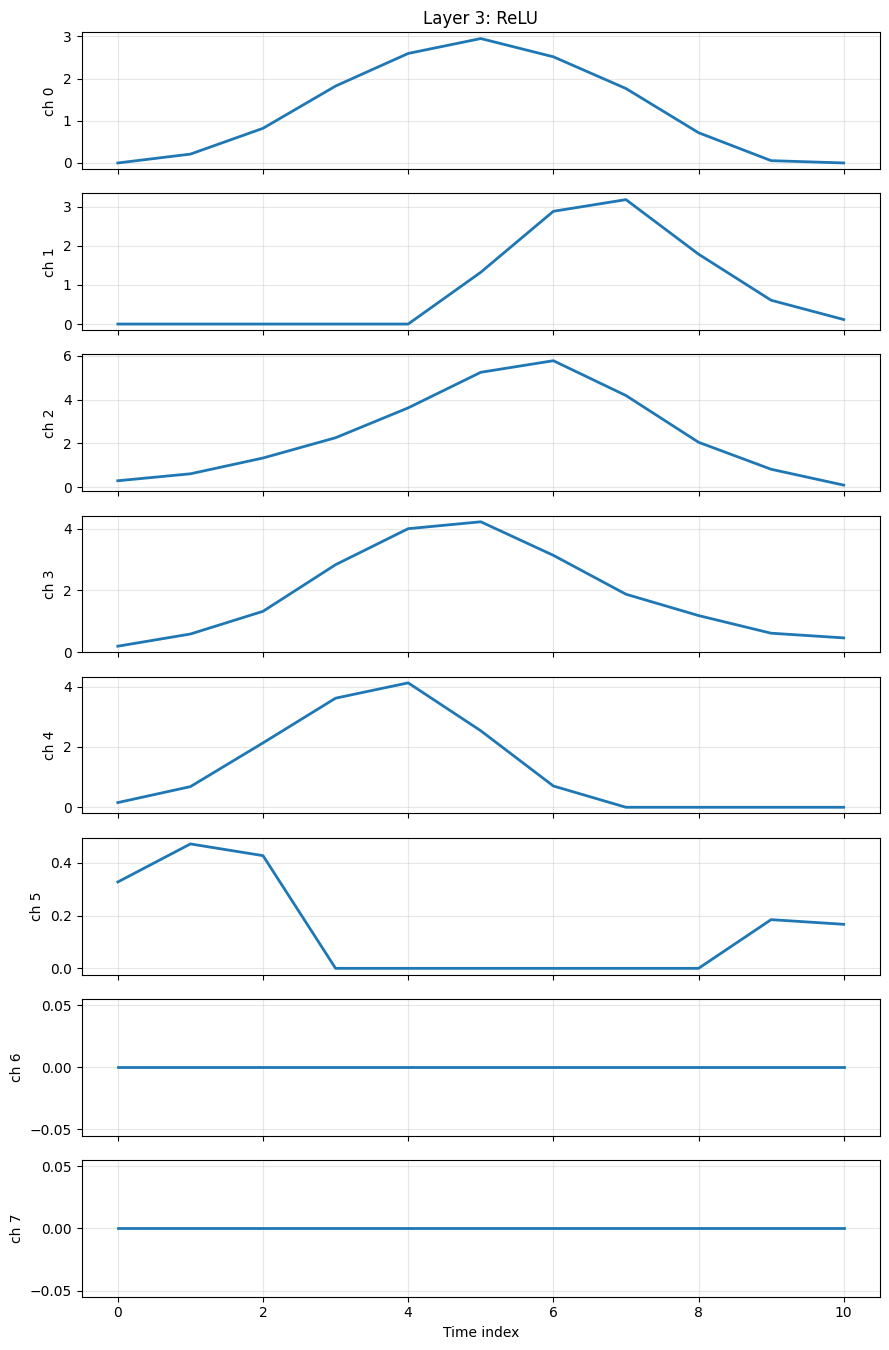

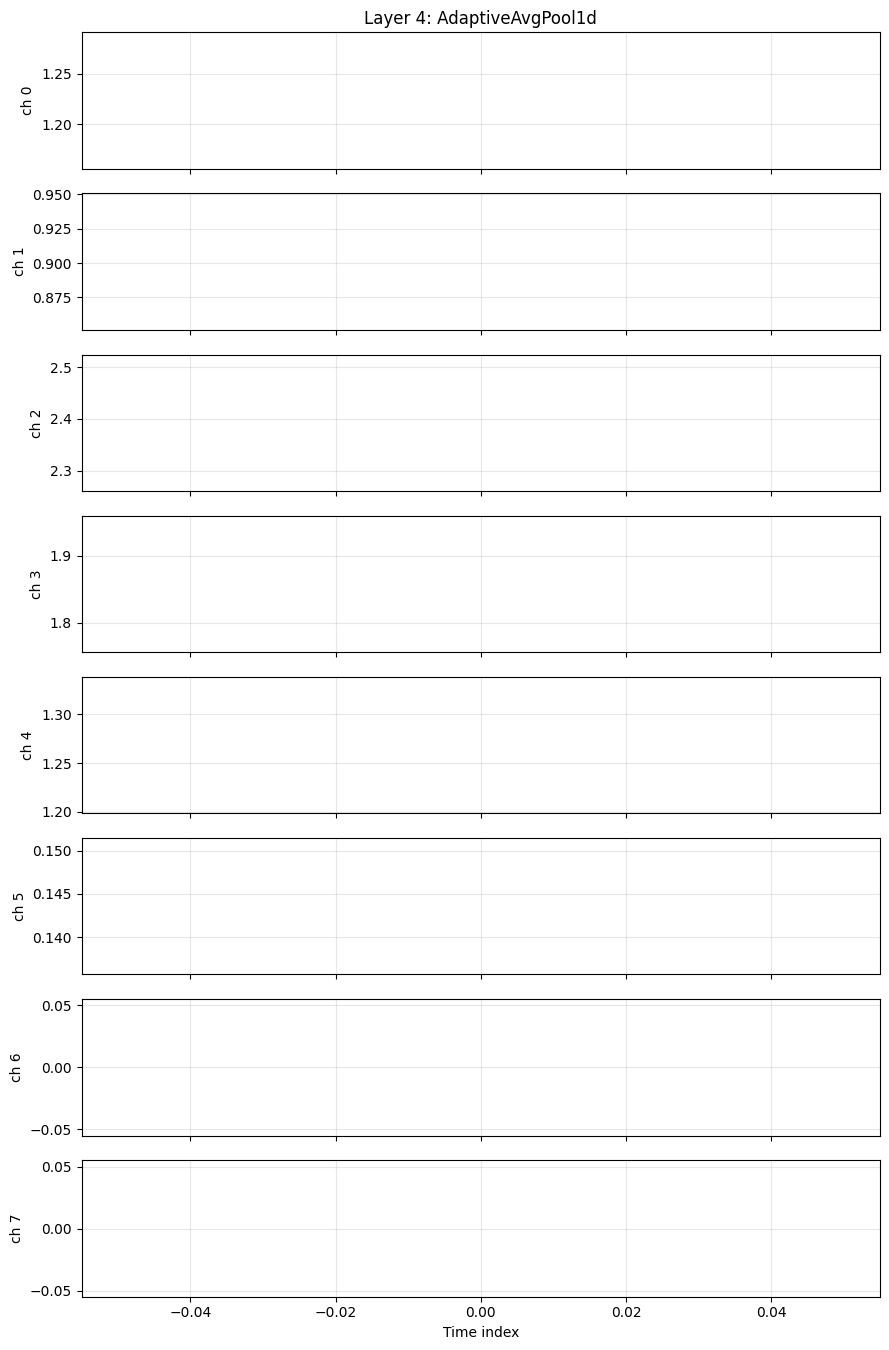

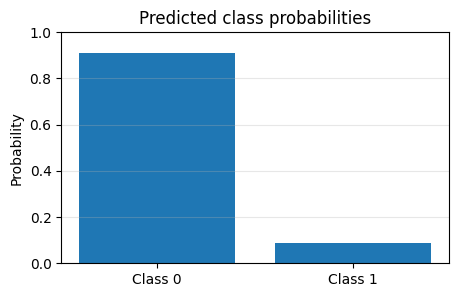


Final output (logits)
 shape: torch.Size([1, 2])
tensor([[ 0.4730, -0.1876]], grad_fn=<AddmmBackward0>)

Final output (class probabilities)
 shape: torch.Size([1, 2])
tensor([[0.6594, 0.3406]], grad_fn=<SoftmaxBackward0>)


In [64]:

model = TinyCNN()
model.eval()

with torch.no_grad():
    stages = []
    stage_names = []

    z_vis = x_torch.clone()
    stages.append(z_vis.squeeze(0).cpu())
    stage_names.append("Input")

    for li, lyr in enumerate(model.features):
        z_vis = lyr(z_vis)
        stages.append(z_vis.squeeze(0).cpu())
        stage_names.append(f"Layer {li}: {lyr.__class__.__name__}")

for name, act in zip(stage_names, stages):
    n_channels, _ = act.shape
    fig, axes = plt.subplots(n_channels, 1, figsize=(9, 1.7 * n_channels), sharex=True)
    if n_channels == 1:
        axes = [axes]

    for ch, ax in enumerate(axes):
        ax.plot(act[ch].numpy(), linewidth=2)
        ax.set_ylabel(f"ch {ch}")
        ax.grid(True, alpha=0.3)

    axes[0].set_title(name)
    axes[-1].set_xlabel("Time index")
    plt.tight_layout()
    plt.show()

with torch.no_grad():
    pooled_vis = z_vis.mean(dim=-1)
    logits_vis = model.classifier(pooled_vis)
    probs_vis = torch.softmax(logits_vis, dim=1).squeeze(0).cpu().numpy()

plt.figure(figsize=(5, 3))
plt.bar(["Class 0", "Class 1"], probs_vis)
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Predicted class probabilities")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Final linear layer
logits = model.classifier(z_pooled)
probs = torch.softmax(logits, dim=1)

print("\nFinal output (logits)")
print(" shape:", logits.shape)
print(logits)

print("\nFinal output (class probabilities)")
print(" shape:", probs.shape)
print(probs)

We can now train the network to classify two classes using signal. The first class contains signals that have a high local peak, while the second class contains signals without the peak. This is just a silly example, the signals could be easily classified based on their maximum value. 

In [65]:
# Build a tiny synthetic dataset for intuition
np.random.seed(0)

n_samples = 50
length = 40
X = []
y = []

for _ in range(n_samples // 2):
    signal = np.random.normal(0, 0.2, length)
    signal[18:22] += np.array([0.5, 1.2, 1.2, 0.5])  # local peak
    X.append(signal)
    y.append(1)

for _ in range(n_samples // 2):
    signal = np.random.normal(0, 0.2, length)
    X.append(signal)
    y.append(0)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

# shape for Conv1d: (samples, channels, length)
X_torch = torch.tensor(X).unsqueeze(1)
y_torch = torch.tensor(y)

print(X_torch.shape, y_torch.shape)

torch.Size([50, 1, 40]) torch.Size([50])


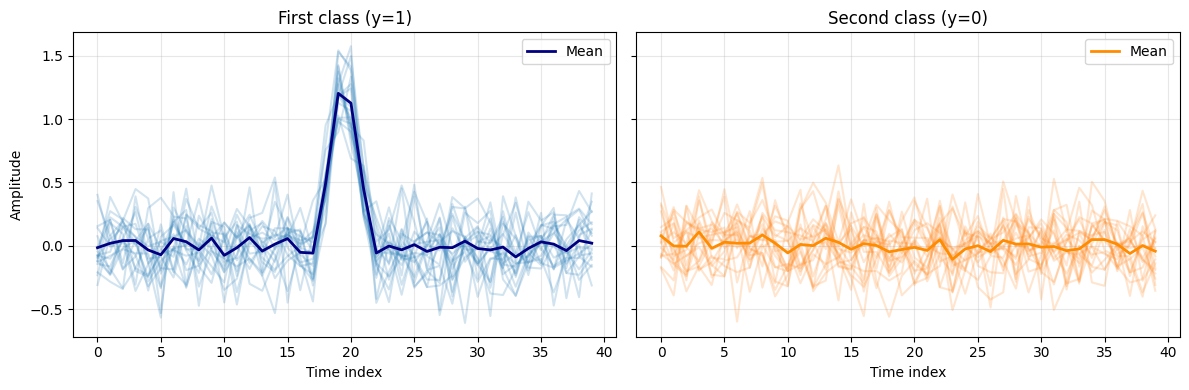

In [66]:
# Plot examples from the first and second classes
idx_first = np.where(y == 1)[0]   # first class in your dataset generation
idx_second = np.where(y == 0)[0]  # second class

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# First class
for k in idx_first[:20]:
    axes[0].plot(X[k], color='tab:blue', alpha=0.2)
axes[0].plot(X[idx_first].mean(axis=0), color='navy', linewidth=2, label='Mean')
axes[0].set_title('First class (y=1)')
axes[0].set_xlabel('Time index')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Second class
for k in idx_second[:20]:
    axes[1].plot(X[k], color='tab:orange', alpha=0.2)
axes[1].plot(X[idx_second].mean(axis=0), color='darkorange', linewidth=2, label='Mean')
axes[1].set_title('Second class (y=0)')
axes[1].set_xlabel('Time index')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

We will train the CNN using a similar loss that we used in logistic regression, because we are predicting the probability of belonging to class 1 or class 0, that is the output of our network, two values between 0 and 1, both of which add up to 1. 

In [67]:
#define the loss
criterion = nn.CrossEntropyLoss()
#define the optimizer, a modified version of stochastic gradient descent that adapts the learning rate for each parameter
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

#do the iterative training loop
for epoch in range(50):
    optimizer.zero_grad()
    logits = model(X_torch)
    loss = criterion(logits, y_torch)
    loss.backward()
    optimizer.step()
    #check performance every 10 repetitions
    if (epoch + 1) % 10 == 0:
        preds = logits.argmax(dim=1)
        acc = (preds == y_torch).float().mean().item()
        print(f'Epoch {epoch+1:02d} | Loss = {loss.item():.4f} | Accuracy = {acc:.4f}')

torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
Epoch 10 | Loss = 0.6797 | Accuracy = 0.5000
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
Epoch 20 | Loss = 0.6471 | Accuracy = 0.9600
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
Epoch 30 | Loss = 0.5728 | Accuracy = 0.9800
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
torch.Size([50, 8])
Epoch 40 | Loss = 0.4358 | Accuracy = 1.0000
torch.Size([50, 8])


An accuracy of 100% likely means that the network overfitted to the training data. This is expected as the problem was simple, and the network has many parameters. 